# Fractional Brownian Motion Parameter Estimation Using Variance Aggregation

Consider a time series of $n$, identically distributed samples,</br>

$
\begin{align}
X_1, X_2,X_3,\ldots,X_n
\end{align}
\tag{1}
$

Divide the series into $d$ smaller series of length $m$ where $md=n$.\ and let, $k = 0,1,2,3,\ldots,d-1$ and define the aggregated sum by,

$
\begin{align}
X_k^m &= \frac{1}{m}\left( X_{km+1} + X_{km+2} + \cdots + X_{km+m-1} + X_{km+m} \right) \\
&= \frac{1}{m} \left( X_{km+1} + \cdots + X_{(k+1)m} \right) \\
&= \frac{1}{m} \sum_{i=km+1}^{(k+1)m} X_i
\end{align}
\tag{2}
$

The aggregated mean is given by,

$
\begin{align}
\text{E}[X^m] &= \frac{1}{d}\sum_{i=1}^d X_i^m \\
&= \frac{1}{dm} \sum_{i=1}^d \sum_{j=im+1}^{(k+1)i} X_j \\
&= \frac{1}{n} \sum_{i=1}^n X_i
\end{align}
\tag{3}
$

and the aggregated variance by,

$
\begin{align}
\text{Var}[X^m] = \frac{1}{d} \sum_{i=1}^d\left( X^m_i - \text{E}[X^m] \right)^2
\end{align}
\tag{4}
$

This method makes use of the self similarity of fractional brownian motion. Consider the aggregated process,

$
\begin{align}
X_0^m = \frac{1}{m} \sum_{i=1}^m X_i
\end{align}
\tag{5}
$

From self similarity of fractional brownian motion,

$
\begin{align}
X_{ai} \sim a^H X_i
\end{align}
\tag{6}
$

Since the distribution of the sum of Gaussian random variables is the distribution of the last it follows that,</br> 

$
\begin{align}
X_0^m \sim \frac{1}{m} X_m \sim \frac{m^H}{m} X_1 = m^{H-1} X_1
\end{align}
\tag{7}
$

For fractional brownian noise,

$
\begin{align}
&\text{E}[\Delta Z^H_t] = 0 \\
&\text{Var}[\Delta Z^H_t] = \Delta t^{2H}
\end{align}
\tag{8}
$

$X_1$ is a single increment of brownian motion it follows that,

$
\begin{align}
\text{Var}[X_1] = \Delta t^{2H} = \sigma^2
\end{align}
\tag{9}
$

so,

$
\begin{align}
\text{Var}[X_0^m] = \text{Var}[m^{H-1} X_1] = m^{2(H-1)}\text{Var}[X_1] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{10}
$

From stationarity of it follows that,

$
\begin{align}
\text{Var}[X_k^m] = \sigma^2 m^{2(H-1)}
\end{align}
\tag{11}
$

It follows that $H$ can be determined by using OLS on $\text{Var}[X_k^m]$ as a function of $m$.

## Imports

In [16]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import variance_agg, stack, curve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [17]:
Δt = 1.0
npts = 2**10
nagg = 100

def var_agg_comparison(t, fbm_noise, H):
    m_vals = [1, 10, 50]
    title = f"Aggregated Fractional Brownian Noise: Δt={Δt}, H={H}"
    labels = [f"m={m}" for m in m_vals]
    params = [{"m": m} for m in m_vals]
    func = lambda **kwargs: stats.compute_agg(t, fbm_noise, **kwargs)
    t_scan, m_scan = create_parameter_scan(func, *params)
    ylabels = [r"$X^1$", r"$X^{10}$", r"$X^{50}$"]
    stack(m_scan, t_scan, ylim=(-3.5, 3.5), ylabels=ylabels, xlabel=r"$t$", title=title, labels=labels, lw=1)

## Simulation $H=0.8$

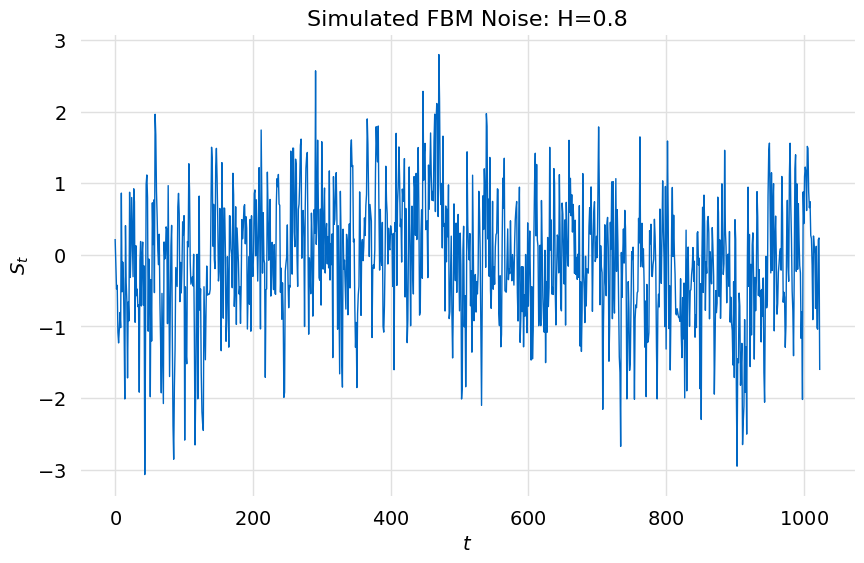

In [18]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

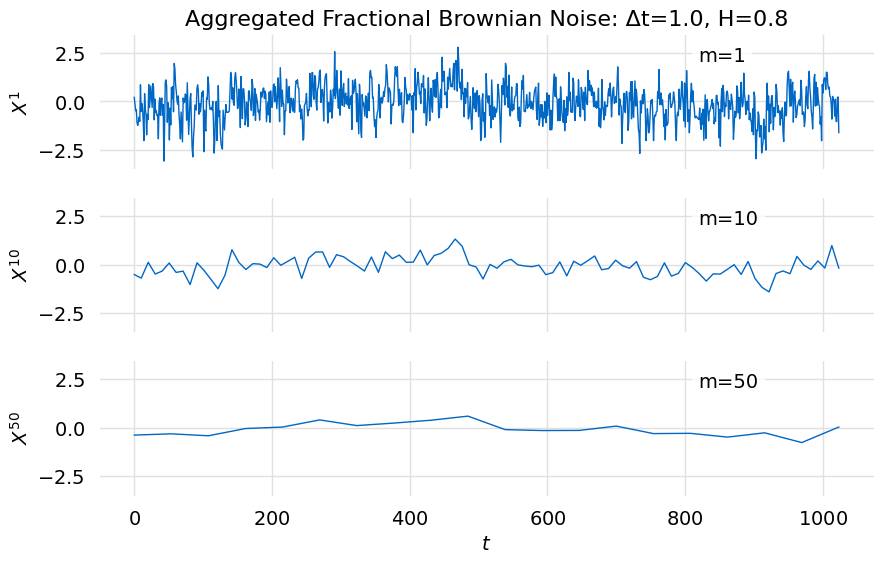

In [19]:
var_agg_comparison(t, fbm_noise, H)

In [20]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [21]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     2182.
Date:                Fri, 24 Nov 2023   Prob (F-statistic):           8.80e-69
Time:                        14:30:07   Log-Likelihood:                 180.00
No. Observations:                 100   AIC:                            -356.0
Df Residuals:                      98   BIC:                            -350.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1276      0.016     -7.773      0.000      -0.160      -0.095
x1            -0.4706      0.010    -46.713      0.000      -0.491      -0.451
==============================================================================
Omnibus:                        0.232   Durbin-Watson:                   1.093
Prob(Omnibus):                  0.891   Jarque-Bera (JB):                0.402
Skew:                          -0.072   Prob(JB):                        0.818
Kurtosis:                       2.725   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.12762747417250464,
      "err": 0.016419544290894057,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "b936a47f-b5a1-4ca2-8116-56496f7837a0",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.4706134424745268,
         "err": 0.010074523708544109,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "b936a47f-b5a1-4ca2-8116-56496f7837a0",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9570198987833111,
   "param_transforms": [
      {
         "param": {
            "est": 0.7646932787627366,
            "err": 0.0050372618542720545,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "b936a47f-b5a1-4

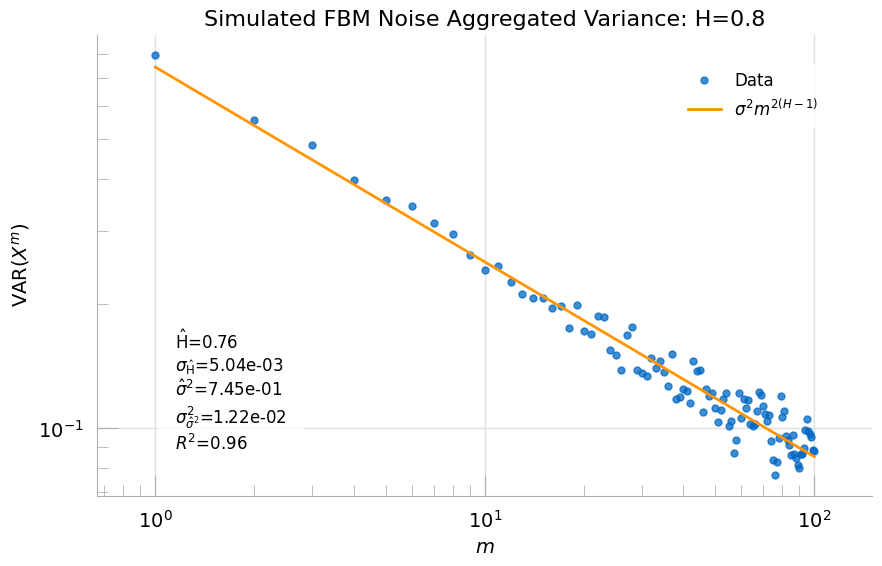

In [23]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.6$

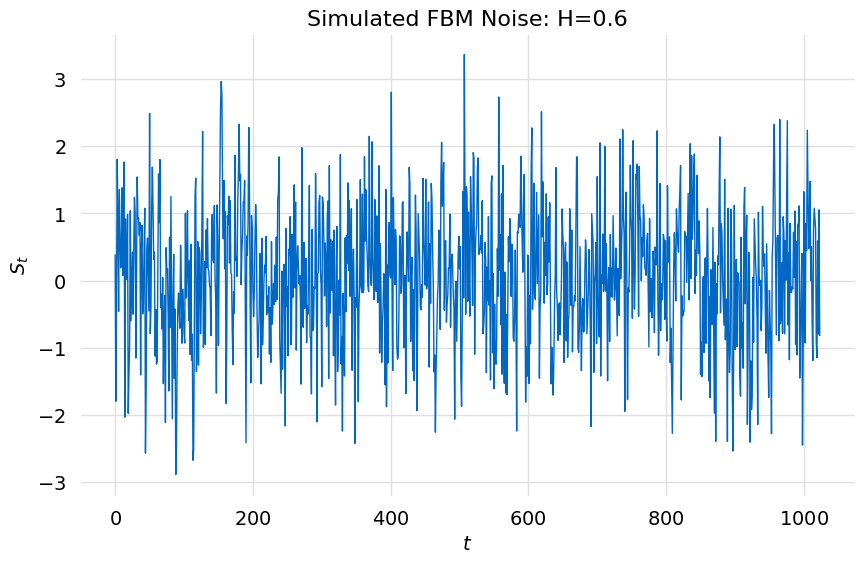

In [24]:
H = 0.6
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

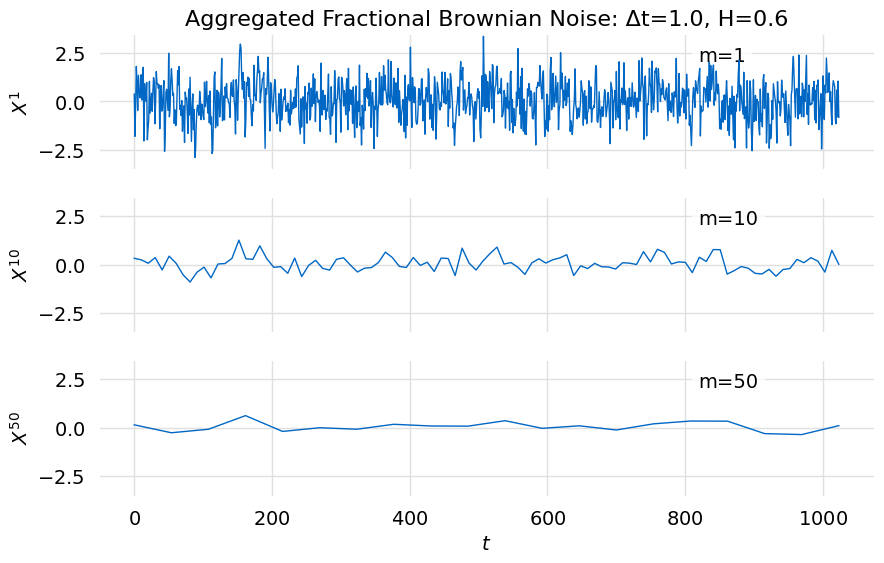

In [25]:
var_agg_comparison(t, fbm_noise, H)

In [26]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [27]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     713.6
Date:                Fri, 24 Nov 2023   Prob (F-statistic):           8.82e-47
Time:                        14:30:08   Log-Likelihood:                 62.528
No. Observations:                 100   AIC:                            -121.1
Df Residuals:                      98   BIC:                            -115.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1186      0.053      2.231      0.028       0.013       0.224
x1            -0.8712      0.033    -26.713      0.000      -0.936      -0.807
==============================================================================
Omnibus:                       27.967   Durbin-Watson:                   0.442
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               47.281
Skew:                          -1.188   Prob(JB):                     5.41e-11
Kurtosis:                       5.387   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [28]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.11859099197888238,
      "err": 0.05315661141513417,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "61ff67af-92d6-40ce-b673-2f13a861b526",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.8712458459260979,
         "err": 0.032615250002073944,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "61ff67af-92d6-40ce-b673-2f13a861b526",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.8792472384851538,
   "param_transforms": [
      {
         "param": {
            "est": 0.5643770770369511,
            "err": 0.016307625001036972,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "61ff67af-92d6-40ce

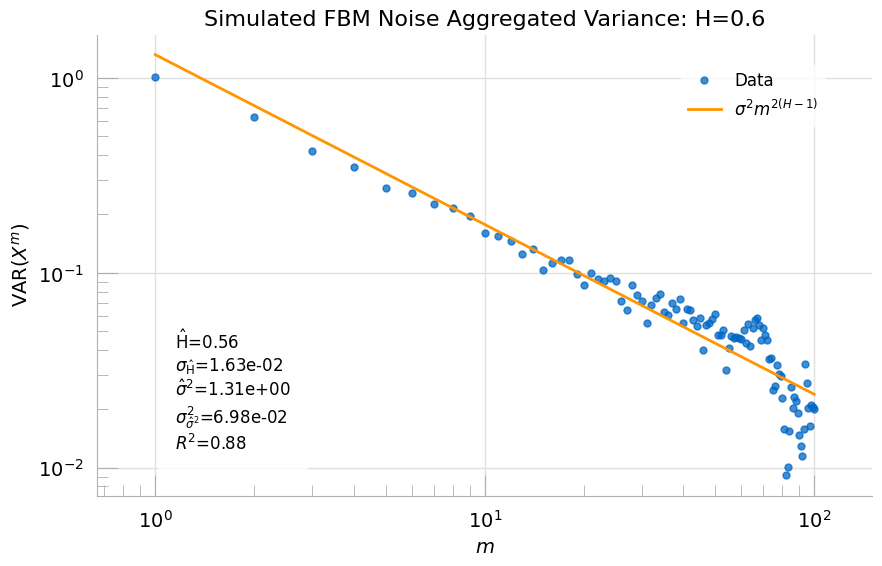

In [29]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.4$

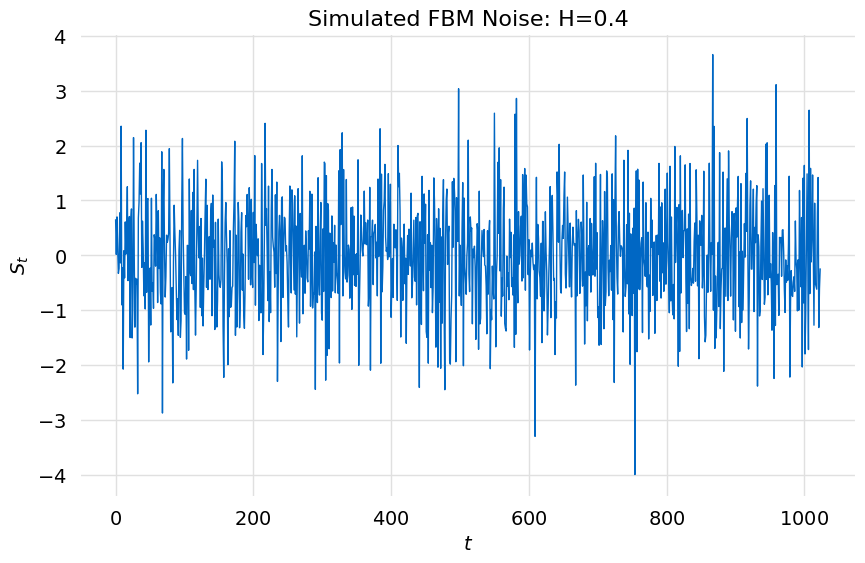

In [30]:
H = 0.4
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

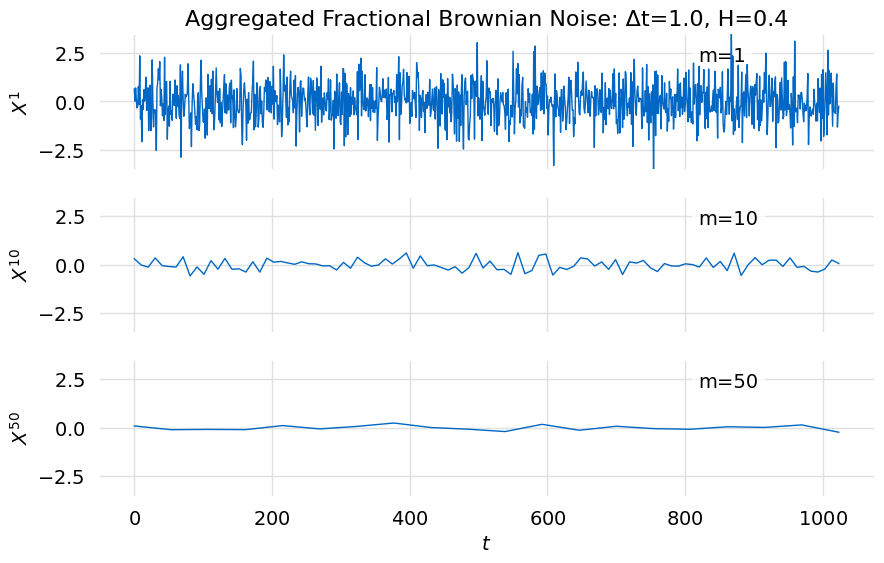

In [31]:
var_agg_comparison(t, fbm_noise, H)

In [32]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [33]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     2620.
Date:                Fri, 24 Nov 2023   Prob (F-statistic):           1.59e-72
Time:                        14:30:09   Log-Likelihood:                 98.402
No. Observations:                 100   AIC:                            -192.8
Df Residuals:                      98   BIC:                            -187.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0139      0.037     -0.373      0.710      -0.088       0.060
x1            -1.1663      0.023    -51.191      0.000      -1.212      -1.121
==============================================================================
Omnibus:                        1.274   Durbin-Watson:                   1.526
Prob(Omnibus):                  0.529   Jarque-Bera (JB):                0.771
Skew:                          -0.156   Prob(JB):                        0.680
Kurtosis:                       3.296   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.01385818746094287,
      "err": 0.03713272919857309,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "63547331-58b5-418f-be21-3914bc97593c",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.1663019452228665,
         "err": 0.02278349228494958,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "63547331-58b5-418f-be21-3914bc97593c",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9639504878869547,
   "param_transforms": [
      {
         "param": {
            "est": 0.4168490273885668,
            "err": 0.01139174614247479,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "63547331-58b5-418f-

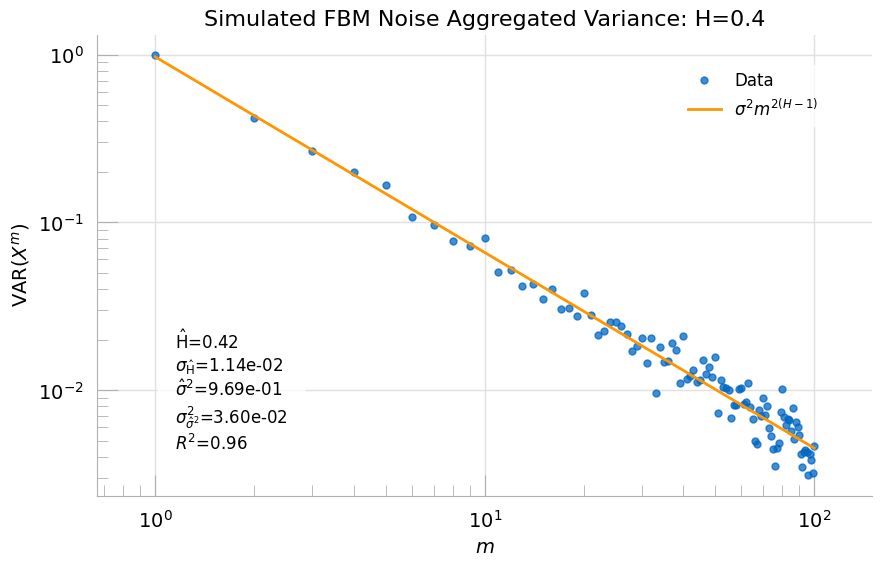

In [35]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")

## Simulation $H=0.2$

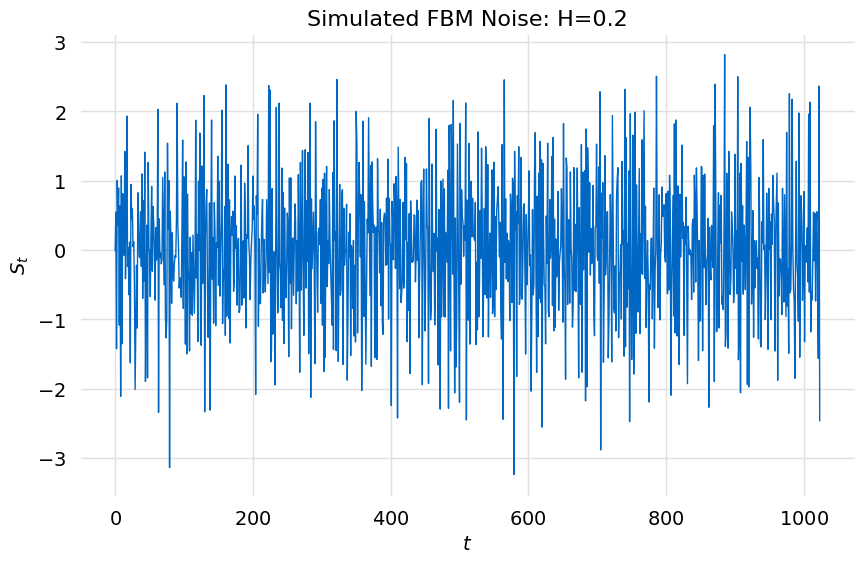

In [36]:
H = 0.2
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

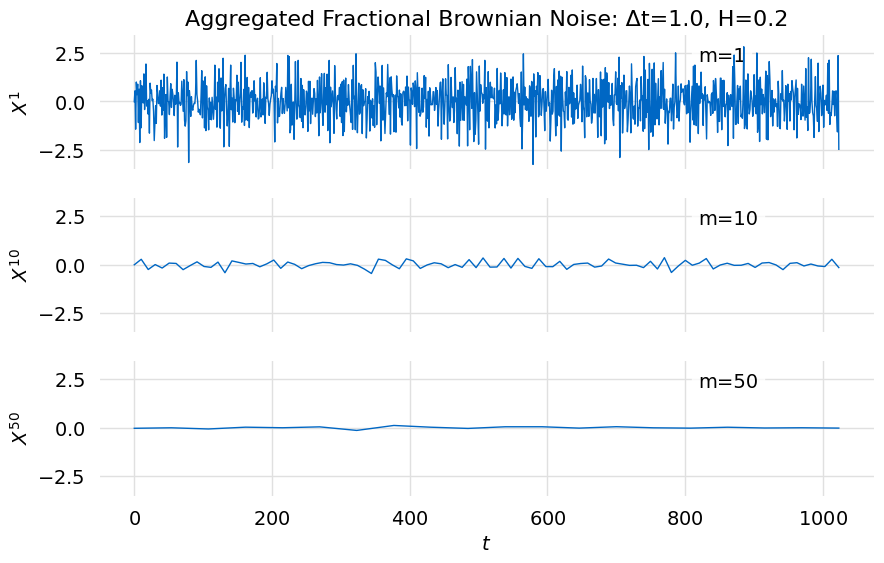

In [37]:
var_agg_comparison(t, fbm_noise, H)

In [38]:
m_vals, agg_var = stats.compute_agg_var(fbm_noise, m_max=nagg, npts=nagg)

In [39]:
result, result_model = fbm.compute_H_estimate_variance_aggregation(m_vals, agg_var)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     2199.
Date:                Fri, 24 Nov 2023   Prob (F-statistic):           6.08e-69
Time:                        14:30:10   Log-Likelihood:                 57.846
No. Observations:                 100   AIC:                            -111.7
Df Residuals:                      98   BIC:                            -106.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0312      0.056      0.560      0.577      -0.079       0.142
x1            -1.6029      0.034    -46.898      0.000      -1.671      -1.535
==============================================================================
Omnibus:                       24.712   Durbin-Watson:                   1.357
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               66.281
Skew:                          -0.823   Prob(JB):                     4.05e-15
Kurtosis:                       6.633   Cond. No.                         9.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.03118047644334357,
      "err": 0.05570418990798561,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "b2c4e71d-e4c0-4896-85c7-62ef142230a1",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -1.6029037881639798,
         "err": 0.03417836524272301,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "b2c4e71d-e4c0-4896-85c7-62ef142230a1",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9573438467165937,
   "param_transforms": [
      {
         "param": {
            "est": 0.1985481059180101,
            "err": 0.017089182621361505,
            "est_label": "$\\hat{\u0397}$",
            "err_label": "$\\sigma_{\\hat{\u0397}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "b2c4e71d-e4c0-4896-

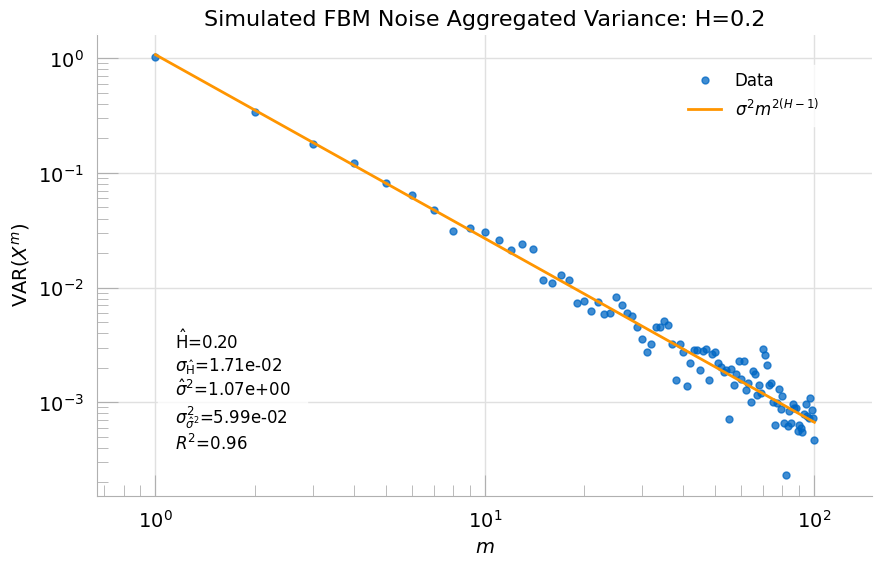

In [41]:
variance_agg(agg_var, result_model, m_vals, title=f"Simulated FBM Noise Aggregated Variance: H={H}")